In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# load the dataset
df = pd.read_csv("raw_fraud_dataset.csv")

In [44]:
# display missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       200 non-null    int64  
 1   amount               200 non-null    float64
 2   channel              200 non-null    str    
 3   latitude             200 non-null    float64
 4   longitude            200 non-null    float64
 5   avg_amount_30d       200 non-null    float64
 6   tx_count_24h         200 non-null    int64  
 7   failed_tx_count_24h  200 non-null    int64  
 8   is_fraud             200 non-null    int64  
dtypes: float64(4), int64(4), str(1)
memory usage: 14.2 KB


In [45]:
# sample 5 rows of the dataset
display(df.head(5))

,transaction_id,amount,channel,latitude,longitude,avg_amount_30d,tx_count_24h,failed_tx_count_24h,is_fraud
0,1,22970000.0,Mobile_Banking,-6.9147,107.6098,5.789341e+06,10,2,0
1,2,132000.0,Mobile_Banking,-6.9147,107.6098,3.702065e+06,6,1,0
2,3,22276000.0,Mobile_Banking,-6.9147,107.6098,5.520589e+06,7,1,0
3,4,381000.0,Web_Portal,-6.9147,107.6098,5.476075e+06,6,0,0
4,5,53000.0,Mobile_Banking,-6.9147,107.6098,3.821067e+06,10,2,0


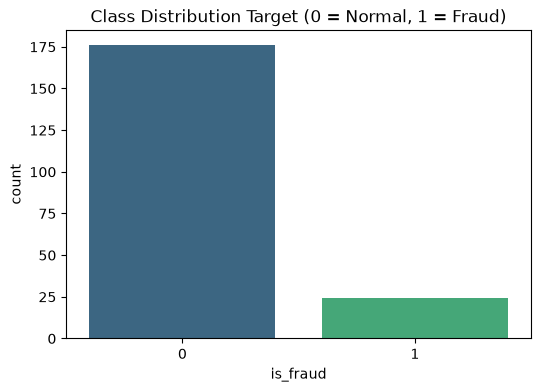

Class Proportion:
is_fraud
0    88.0
1    12.0
Name: proportion, dtype: float64


In [46]:
# class imbalance analysis
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_fraud", palette="viridis")
plt.title("Class Distribution Target (0 = Normal, 1 = Fraud)")
plt.show()

# proportion presentation
proportion = df["is_fraud"].value_counts(normalize=True) * 100
print(f"Class Proportion:\n{proportion}")

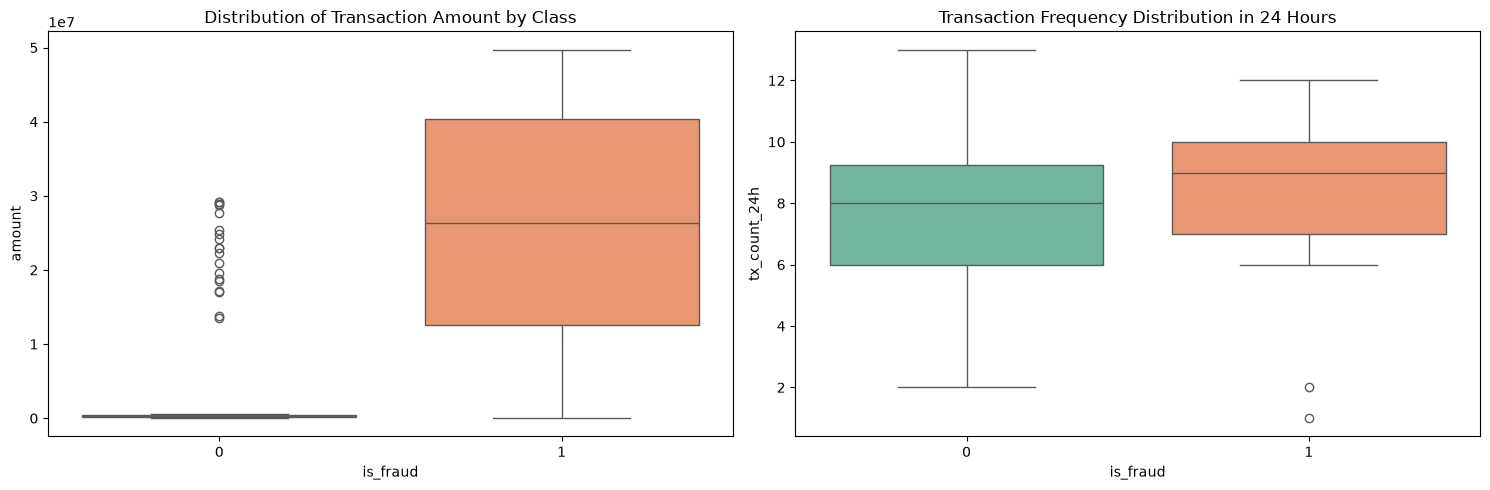

In [47]:
# feature distribution analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# distribution of nominal transaction
sns.boxplot(data=df, x='is_fraud', y='amount', ax=axes[0], palette="Set2")
axes[0].set_title("Distribution of Transaction Amount by Class")

# transaction frequency distribution in 24 hours
sns.boxplot(data=df, x='is_fraud', y='tx_count_24h', ax=axes[1], palette="Set2")
axes[1].set_title("Transaction Frequency Distribution in 24 Hours")

plt.tight_layout()
plt.show()

In [48]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in kilometers

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    distance = R * c
    return distance

# TMP user coordinates (latitude and longitude) in bandung
HOME_LAT, HOME_LON = -6.9147, 107.6098

# create a new feature for distance from home
df['distance_from_home'] = haversine_distance(HOME_LAT, HOME_LON, df['latitude'], df['longitude'])

# drop column that are not needed
df = df.drop(columns=['transaction_id', 'latitude', 'longitude'])

display(df.head())

,amount,channel,avg_amount_30d,tx_count_24h,failed_tx_count_24h,is_fraud,distance_from_home
0,22970000.0,Mobile_Banking,5.789341e+06,10,2,0,0.0
1,132000.0,Mobile_Banking,3.702065e+06,6,1,0,0.0
2,22276000.0,Mobile_Banking,5.520589e+06,7,1,0,0.0
3,381000.0,Web_Portal,5.476075e+06,6,0,0,0.0
4,53000.0,Mobile_Banking,3.821067e+06,10,2,0,0.0


In [49]:
# Encoding categorical features
df = pd.get_dummies(df, columns=['channel'], drop_first=True)

# make sure all boolean features are in integer format
df = df.astype({col: int for col in df.select_dtypes('bool').columns})

display(df.head())

,amount,avg_amount_30d,tx_count_24h,failed_tx_count_24h,is_fraud,distance_from_home,channel_Web_Portal
0,22970000.0,5.789341e+06,10,2,0,0.0,0
1,132000.0,3.702065e+06,6,1,0,0.0,0
2,22276000.0,5.520589e+06,7,1,0,0.0,0
3,381000.0,5.476075e+06,6,0,0,0.0,1
4,53000.0,3.821067e+06,10,2,0,0.0,0


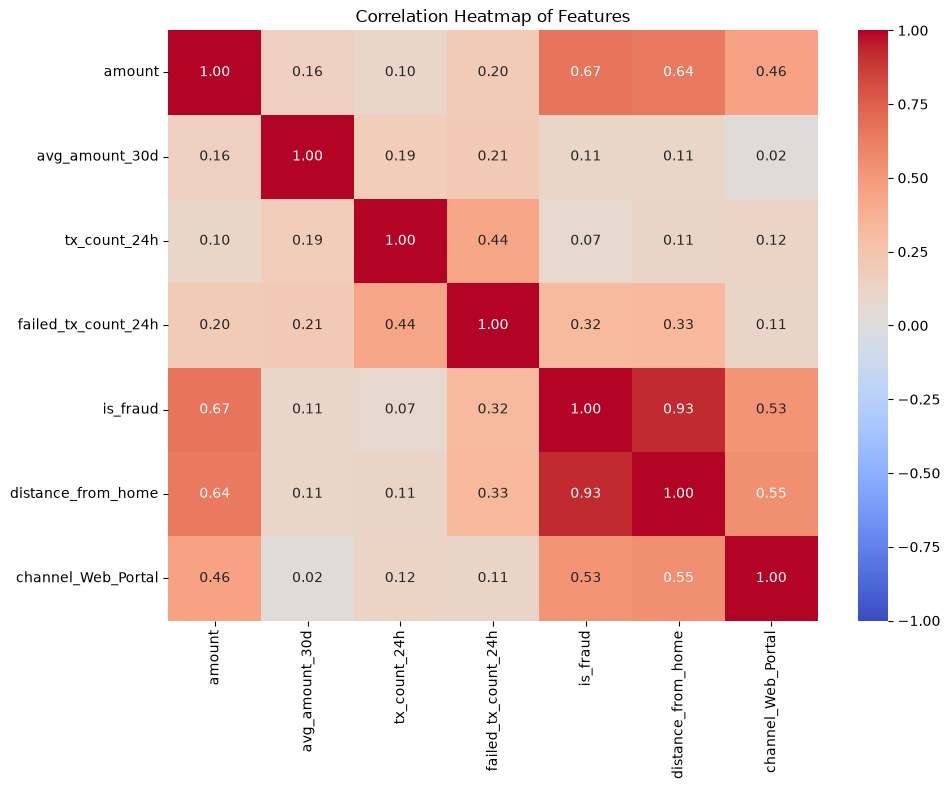

In [50]:
# create a correlation heatmap
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.show()

In [51]:
from sklearn.preprocessing import RobustScaler

X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

scaler = RobustScaler()
feature_names = X.columns

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

display(X_scaled_df.describe().round(2))

,amount,avg_amount_30d,tx_count_24h,failed_tx_count_24h,distance_from_home,channel_Web_Portal
count,200.00,200.00,200.00,200.00,200.00,200.00
mean,17.21,-0.47,-0.04,-0.10,1242.36,0.23
std,38.74,1.81,0.76,0.89,3636.25,0.42
min,-1.13,-7.98,-2.33,-1.00,0.00,0.00
25%,-0.55,-0.59,-0.33,-1.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.45,0.41,0.67,0.00,0.00,0.00
max,163.31,2.15,1.67,2.00,11832.02,1.00


Before SMOTE, class distribution in training set:
is_fraud
0    141
1     19
Name: count, dtype: int64
After SMOTE, class distribution in training set:
is_fraud
0    141
1    141
Name: count, dtype: int64
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        35
           1       1.00      0.80      0.89         5

    accuracy                           0.97        40
   macro avg       0.99      0.90      0.94        40
weighted avg       0.98      0.97      0.97        40



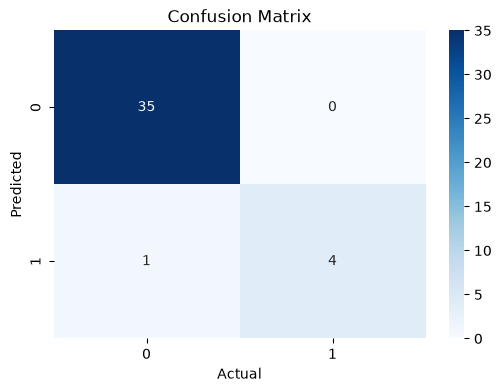

Model and scaler saved successfully.


In [54]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import joblib

# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

# apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE, class distribution in training set:")
print(y_train.value_counts())
print("After SMOTE, class distribution in training set:")
print(y_train_balanced.value_counts())

# train a Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)

# model testing
y_pred = rf_model.predict(X_test)

# evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

joblib.dump(rf_model, "fraud_rf_model.pkl")
joblib.dump(scaler, "robust_scaler.pkl")
print("Model and scaler saved successfully.")